In [61]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt, argrelextrema

In [203]:
#df = pd.read_csv("../DMP_9D_ACCEL_Logs/cleaned_new/curl/curl.14.csv") # cut off freq = 0.5
#df = pd.read_csv("../DMP_9D_ACCEL_Logs/cleaned_new/shoulder_press/shoulder_press.14.csv") # cut off freq = 1
df = pd.read_csv("../DMP_9D_ACCEL_Logs/cleaned_new/front_raise/front_raise.1.csv") # cut off freq = 1
#df = pd.read_csv("../DMP_9D_ACCEL_Logs/cleaned_new/dataset/hammer_curl.12.csv") # cut off freq = 1

In [204]:
tSec = (df['timestamp'] - df['timestamp'].iloc[0])/1000
fs = 1 / (tSec[1] - tSec[0])  # Sampling frequency
print(fs)

58.8235294117647


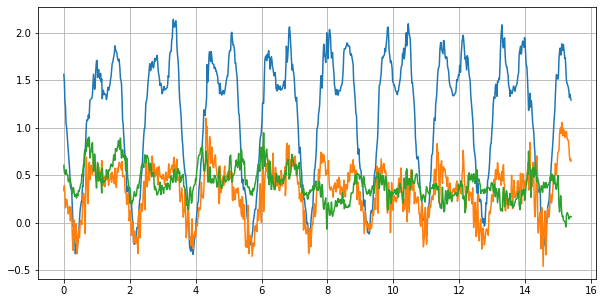

In [205]:
plt.figure(figsize=[10, 5])
plt.plot(tSec, df['ax'], label='ax')
plt.plot(tSec, df['ay'], label='ay')
plt.plot(tSec, df['az'], label='az')
plt.grid()

In [206]:
df['aMagnitude'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)

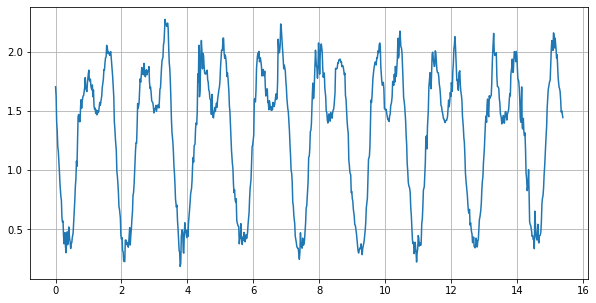

In [207]:
plt.figure(figsize=[10, 5])
plt.plot(tSec, df['aMagnitude'], label='ax')
plt.grid()

In [208]:
def butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return y

In [209]:
# Apply lowpass filter to remove noise
cutoff_low = .7 # Lowpass filter cutoff frequency (Hz)
df['aMagnitudeFiltered'] = lowpass_filter(df['aMagnitude'], cutoff_low, fs, order=10)

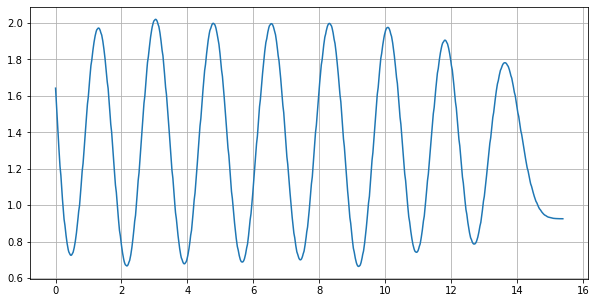

In [210]:
plt.figure(figsize=[10, 5])
plt.plot(tSec, df['aMagnitudeFiltered'], label='aMagnitudeFiltered')
plt.grid()

<AxesSubplot:xlabel='timestamp'>

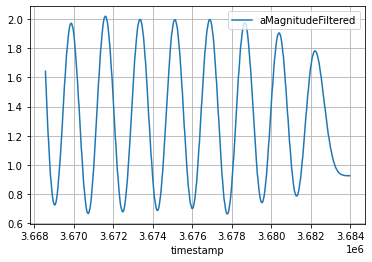

In [211]:
df.plot(x = 'timestamp', y = 'aMagnitudeFiltered', grid=True)

In [212]:
indecies = argrelextrema(df['aMagnitudeFiltered'].values, np.greater)
print(len(indecies[0]))


8


In [213]:
peaks = df.iloc[indecies]

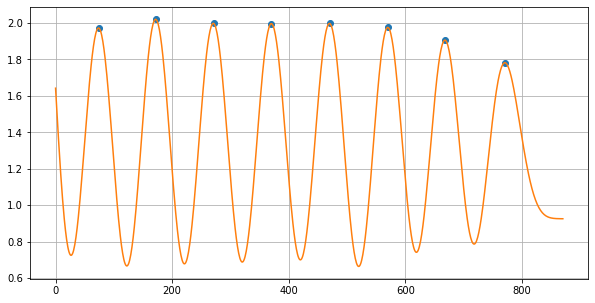

In [214]:
plt.figure(figsize=[10, 5])
plt.plot(peaks['aMagnitudeFiltered'], 'o', label='peaks')
plt.plot(df['aMagnitudeFiltered'])
plt.grid()

In [215]:
# Calculate the intervals between peaks to determine repetitions
peak_intervals = np.diff(peaks['timestamp'])

In [216]:
peak_intervals/1000.

array([1.735, 1.748, 1.757, 1.765, 1.776, 1.731, 1.826])

In [222]:
# Get mean of intervals
mean_interval = np.mean(peak_intervals)

In [226]:
tolerance = 0.6 * mean_interval  # 20% tolerance
repetitions = np.sum((peak_intervals > (mean_interval - tolerance)) & (peak_intervals < (mean_interval + tolerance)))
print(f"Number of repetitions: {repetitions}")

Number of repetitions: 7
